In [31]:
import sys, os, imp
#import importlib.util as imp
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import lambda2nu, nu2lambda, c

In [32]:
from IPython.core.display import HTML
from IPython.core.pylabtools import figsize
from IPython.display import display, Math

In [49]:
lumapiFile = "C:\\Program Files\\Lumerical\\v221\\api\\python\\lumapi.py"
luma = imp.load_source("lumapi", lumapiFile)
fdtdApi = luma.FDTD(hide = False)

Exception ignored in: <function Lumerical.__del__ at 0x000002A615F5E660>
Traceback (most recent call last):
  File "C:\Program Files\Lumerical\v221\api\python\lumapi.py", line 1196, in __del__
    close(self.handle)
  File "C:\Program Files\Lumerical\v221\api\python\lumapi.py", line 245, in close
    iapi.appClose(handle)
ctypes.ArgumentError: argument 1: TypeError: expected Session instance instead of Session


In [34]:
if True:
    matname = "Si (Silicon) - Dispersive & Lossless";
    newmaterial = fdtdApi.addmaterial("Lorentz");
    fdtdApi.setmaterial(newmaterial,"name",matname);
    fdtdApi.setmaterial(matname,"Permittivity",7.98737492);
    fdtdApi.setmaterial(matname,"Lorentz Linewidth",1e8);
    fdtdApi.setmaterial(matname,"Lorentz Resonance",3.93282466e+15);
    fdtdApi.setmaterial(matname,"Lorentz Permittivity",3.68799143);
    fdtdApi.setmaterial(matname,"color",np.array([0.85, 0, 0, 1])); # re
    matname = "SiO2 (Glass) - Dispersive & Lossless";
    newmaterial = fdtdApi.addmaterial("Lorentz");
    fdtdApi.setmaterial(newmaterial,"name",matname);
    fdtdApi.setmaterial(matname,"Permittivity",2.119881);
    fdtdApi.setmaterial(matname,"Lorentz Linewidth",1e10);
    fdtdApi.setmaterial(matname,"Lorentz Resonance",3.309238e+13);
    fdtdApi.setmaterial(matname,"Lorentz Permittivity", 49.43721);
    fdtdApi.setmaterial(matname,"color",np.array([0.5, 0.5, 0.5, 1])); # grey



In [50]:
um = 1e-6
nm = 1e-9

In [51]:
n_c = 1.444
n_r = 3.476
lambda_0 = 1550*nm
Wm = 7*um
k_0 = 2*np.pi/lambda_0
N = 2



In [52]:
sigma = 0
We = Wm + (lambda_0/ np.pi) * (n_c/n_r)**(2*0) * (n_r**2 - n_c**2)**(-1/2)
We/um

7.1560405319904525

In [38]:
"""neff_app = np.zeros(6)
for i in range (6):
    neff_app[i] = n_r - ((i+1)**2 * np.pi * lambda_0)/(We**2 * 4 * n_r * k_0)
    kc = (i+1)* np.pi / We
    print("neff_app = %4.5f" %neff_app[i])"""

'neff_app = np.zeros(6)\nfor i in range (6):\n    neff_app[i] = n_r - ((i+1)**2 * np.pi * lambda_0)/(We**2 * 4 * n_r * k_0)\n    kc = (i+1)* np.pi / We\n    print("neff_app = %4.5f" %neff_app[i])'

In [39]:
"""Lpi = 2*np.pi / (neff_app[0] - neff_app[2])/k_0
Lpi/um
#Lpi2 = (4*n_r*We**2)/(3*lambda_0)
#Lpi2/um"""

'Lpi = 2*np.pi / (neff_app[0] - neff_app[2])/k_0\nLpi/um\n#Lpi2 = (4*n_r*We**2)/(3*lambda_0)\n#Lpi2/um'

In [53]:
#L = 3*Lpi/N
#L = 0.5*Lpi
L = 177.5*um
L/um
#L = L/4

177.5

In [54]:
# PARAMETERS 
taper_heigth = 15*um
taper_width = 1.5*um

wg_width = 450*nm
wg_heigth = 220*nm

x_span_rect = 4*um

x_taper = L/2 + taper_heigth/2
#y_taper = We/6
y_taper = (Wm/2-taper_width)+(taper_width/2)

lambda_start = 1.5*um
lambda_stop = 1.6*um
num_points = 100

material_wg = "Si (Silicon) - Palik"
material_background = "SiO2 (Glass) - Palik"

#material_background = "SiO2 (Glass) - Dispersive & Lossless"
#material_wg = "Si (Silicon) - Dispersive & Lossless"
filename = "S_MMI_FDTD_2x2_%d_um_TE" %(L/um)


In [55]:
fdtdApi.addstructuregroup()
dev_layer = "GDS_LAYER_35:4"
fdtdApi.set("name", dev_layer)

In [56]:
# Criação do dispositivo

# caixa central
fdtdApi.addrect()
fdtdApi.addtogroup(dev_layer)
fdtdApi.set("name", "box")
fdtdApi.set("x", 0)
fdtdApi.set("y", 0)
fdtdApi.set("z", wg_heigth/2)
fdtdApi.set("x span", L)
fdtdApi.set("y span",Wm)
fdtdApi.set("z span", wg_heigth)
fdtdApi.set("material", material_wg)


#tapers
fdtdApi.addobject("linear_taper")
fdtdApi.set("name", "taper1")
fdtdApi.set("angle_side", 90)
fdtdApi.set("width_r", taper_width)
fdtdApi.set("width_l", wg_width)
fdtdApi.set("len", taper_heigth)
fdtdApi.set("material", material_wg)
fdtdApi.set("thickness", wg_heigth)
fdtdApi.set("x", -x_taper)
fdtdApi.set("y", y_taper)
fdtdApi.set("z", wg_heigth/2)

fdtdApi.copy()
fdtdApi.set("name", "taper2")
fdtdApi.set("y", -y_taper)

fdtdApi.copy()
fdtdApi.set("name", "taper3")
fdtdApi.set("y", y_taper)
fdtdApi.set("width_l", taper_width)
fdtdApi.set("width_r", wg_width)
fdtdApi.set("x", x_taper)

fdtdApi.copy()
fdtdApi.set("name", "taper4")
fdtdApi.set("y", -y_taper)

fdtdApi.addrect()
fdtdApi.addtogroup(dev_layer)
fdtdApi.set("name", "rect_port1")
fdtdApi.set("x", -(x_taper + taper_heigth/2 + x_span_rect/2))
fdtdApi.set("y", y_taper)
fdtdApi.set("z", wg_heigth/2)
fdtdApi.set("x span", x_span_rect)
fdtdApi.set("y span", wg_width)
fdtdApi.set("z span", wg_heigth)
fdtdApi.set("material", material_wg)

fdtdApi.copy()
fdtdApi.set("name", "rect_port2")
fdtdApi.set("y", -y_taper)

fdtdApi.copy()
fdtdApi.set("name", "rect_port3")
fdtdApi.set("y", y_taper)
fdtdApi.set("x", (x_taper + taper_heigth/2 + x_span_rect/2))

fdtdApi.copy()
fdtdApi.set("name", "rect_port4")
fdtdApi.set("y", -y_taper)






In [ ]:
bound_x_offset = 0.5*um
bound_y_offset = 2*um
bound_z_offset = 0.5*um
x_span_solver = L+2*taper_heigth+2*x_span_rect-2*bound_x_offset
time_simulation = (L +2*taper_heigth+2*x_span_rect)*7/c + 200e-15

fdtdApi.addfdtd()
fdtdApi.set("x", 0)
fdtdApi.set("y", 0)
fdtdApi.set("z", wg_heigth/2)
fdtdApi.set("x span", x_span_solver)
fdtdApi.set("y span", Wm+2*bound_y_offset)
fdtdApi.set("z span", wg_heigth/2 + 2*bound_z_offset)
fdtdApi.set("background material", material_background)
fdtdApi.set("simulation time", time_simulation)


fdtdApi.set("mesh accuracy", 3)

fdtdApi.set("z min bc", "Symmetric")
fdtdApi.set("z max bc", "PML")

fdtdApi.set("global source wavelength start", lambda_start)
fdtdApi.set("global source wavelength stop", lambda_stop)


In [58]:
fdtdApi.addport()
fdtdApi.set("name", "port_1")
fdtdApi.set("x", -x_span_solver/2 + 1*um)
fdtdApi.set("y", y_taper)
fdtdApi.set("z", wg_heigth/2)
fdtdApi.set("y span", 4*um)
fdtdApi.set("z span", 4*um)
fdtdApi.set("mode selection", "fundamental TE mode")
fdtdApi.set("direction", "Forward")

fdtdApi.copy()
fdtdApi.set("name", "port_2")
fdtdApi.set("y", -y_taper)

fdtdApi.copy()
fdtdApi.set("name", "port_3")
fdtdApi.set("x", x_span_solver/2 - 1*um)
fdtdApi.set("y", y_taper)
fdtdApi.set("direction", "Backward")


fdtdApi.copy()
fdtdApi.set("name", "port_4")
fdtdApi.set("y", -y_taper)

fdtdApi.select("FDTD::ports")
fdtdApi.set("monitor frequency points", num_points)




In [59]:
fdtdApi.addprofile()
fdtdApi.set("name", "Monitor E")
fdtdApi.set("x", 0)
fdtdApi.set("y", 0)
fdtdApi.set("z", wg_heigth/2)
fdtdApi.set("x span", x_span_solver)
fdtdApi.set("y span", Wm+2*bound_y_offset)
fdtdApi.set("override global monitor settings", True)
fdtdApi.set("frequency points", num_points)

In [60]:
fdtdApi.save(filename)

In [62]:
fdtdApi.run(3)

In [63]:
E = fdtdApi.getresult("Monitor E", "E")

x = E["x"]
x = x[:,0]/um

y = E["y"]
y = y[:,0]/um

z = E["z"]
E = E["E"]

Ex = E[:,:,0,:,0]
Ey = E[:,:,0,:,1]
Ez = E[:,:,0,:,2]

Emag = np.sqrt(np.abs(Ex)**2 + np.abs(Ey)**2 + Ez**2)

c:\Users\Isa Cristina\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\contour.py:1364: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = z.max().astype(float)
c:\Users\Isa Cristina\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\contour.py:1365: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = z.min().astype(float)
c:\Users\Isa Cristina\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\ma\core.py:2885: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


<function matplotlib.pyplot.show(close=None, block=None)>

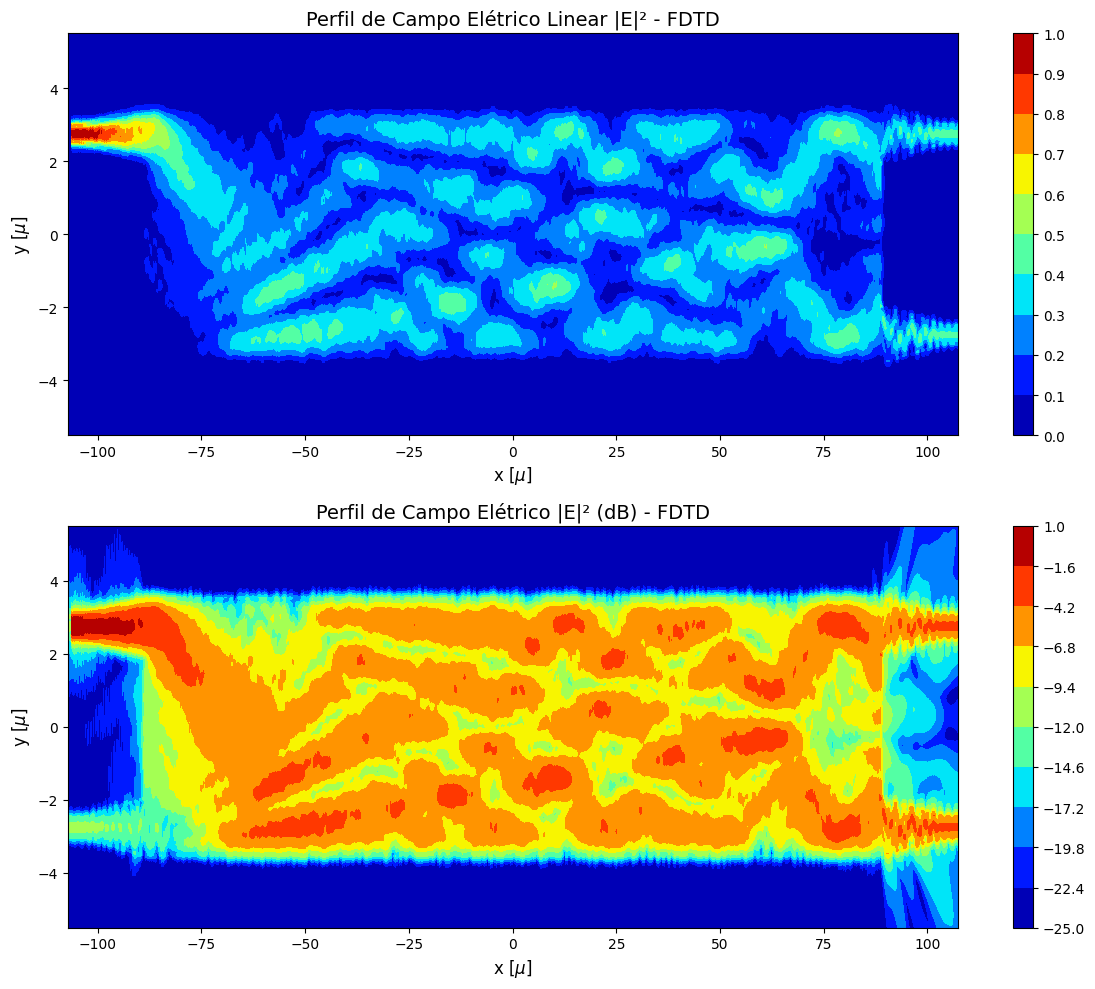

In [64]:
fig,axs = plt.subplots(2,1,figsize= (12,10))


mycmap1 = plt.get_cmap("jet")

v1 = np.linspace(0,1,11, endpoint=True)

cp1 = axs[0].contourf(x, y, np.clip(np.transpose(Emag[:,:,0]), v1.min(), v1.max()), v1, cmap = mycmap1)
plt.colorbar(cp1, ax=axs[0], ticks=v1)

axs[0].set_xlabel(r"x [$\mu$]", fontsize=12)
axs[0].set_ylabel(r"y [$\mu$]", fontsize=12)
axs[0].set_title("Perfil de Campo Elétrico Linear |E|² - FDTD", fontsize = 14)

mycmap2 = plt.get_cmap("jet")

v2 = np.linspace(-25,1,11, endpoint=True)

cp2 = axs[1].contourf(x, y, np.clip(10*np.log10(np.transpose(Emag[:,:,0])), v2.min(), v2.max()), v2, cmap = mycmap2)
plt.colorbar(cp2, ax=axs[1], ticks=v2)

axs[1].set_xlabel(r"x [$\mu$]", fontsize=12)
axs[1].set_ylabel(r"y [$\mu$]", fontsize=12)
axs[1].set_title("Perfil de Campo Elétrico |E|² (dB) - FDTD", fontsize = 14)

plt.tight_layout()
plt.savefig("Perfil de campo - FDTD - TE.png")
plt.show



In [66]:
T1 = fdtdApi.getresult("FDTD::ports::port_1", "T")
T2 = fdtdApi.getresult("FDTD::ports::port_2", "T")
T3 = fdtdApi.getresult("FDTD::ports::port_3", "T")
T4 = fdtdApi.getresult("FDTD::ports::port_4", "T")

T1_dB = 10*np.log10(np.abs(T1["T"]))
T2_dB = 10*np.log10(np.abs(T2["T"]))
T3_dB = 10*np.log10(np.abs(T3["T"]))
T4_dB = 10*np.log10(np.abs(T4["T"]))

<function matplotlib.pyplot.show(close=None, block=None)>

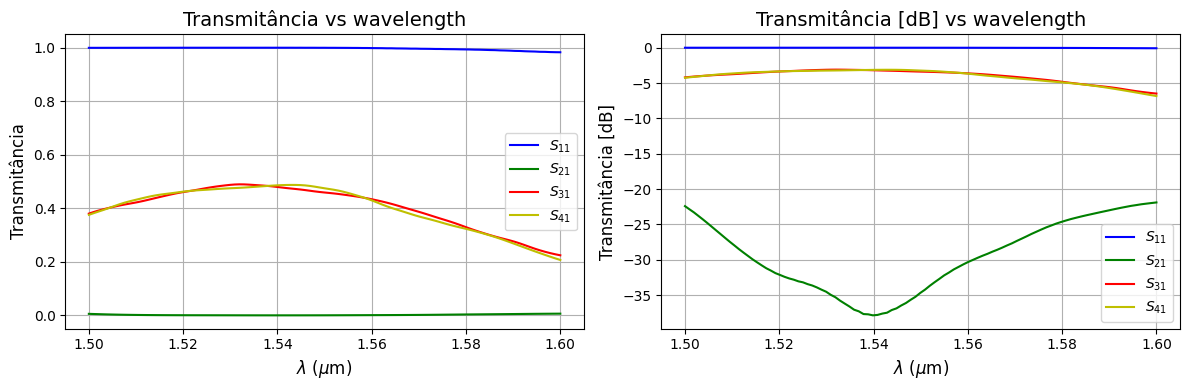

In [78]:
fig1,axs1 = plt.subplots(1,2,figsize= (12,4))

axs1[0].plot(T1["lambda"]/um, np.abs(T1["T"]), "b", lw = 1.5, label = "$S_{11}$")
axs1[0].plot(T2["lambda"]/um, np.abs(T2["T"]), "g", lw = 1.5, label = "$S_{21}$")
axs1[0].plot(T3["lambda"]/um, np.abs(T3["T"]), "r", lw = 1.5, label = "$S_{31}$")
axs1[0].plot(T4["lambda"]/um, np.abs(T4["T"]), "y", lw = 1.5, label = "$S_{41}$")
axs1[0].set_xlabel(r"$\lambda$ ($\mu$m)", fontsize = 12)
axs1[0].set_ylabel(r"Transmitância", fontsize = 12)
axs1[0].set_title(r"Transmitância vs wavelength", fontsize = 14)
#axs1[0].set_ylim(0.0, 0.5)
axs1[0].grid()
axs1[0].legend()

axs1[1].plot(T1["lambda"]/um, T1_dB, "b", lw = 1.5, label = "$S_{11}$")
axs1[1].plot(T2["lambda"]/um, T2_dB, "g", lw = 1.5, label = "$S_{21}$")
axs1[1].plot(T3["lambda"]/um, T3_dB, "r", lw = 1.5, label = "$S_{31}$")
axs1[1].plot(T4["lambda"]/um, T4_dB, "y", lw = 1.5, label = "$S_{41}$")
axs1[1].set_xlabel(r"$\lambda$ ($\mu$m)", fontsize = 12)
axs1[1].set_ylabel(r"Transmitância [dB]", fontsize = 12)
axs1[1].set_title(r"Transmitância [dB] vs wavelength", fontsize = 14)
#axs1[1].set_ylim(-6, 0)
axs1[1].grid()
axs1[1].legend()

plt.tight_layout()
plt.savefig("Transmissao vs box length - FDTD - TE.png")
plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

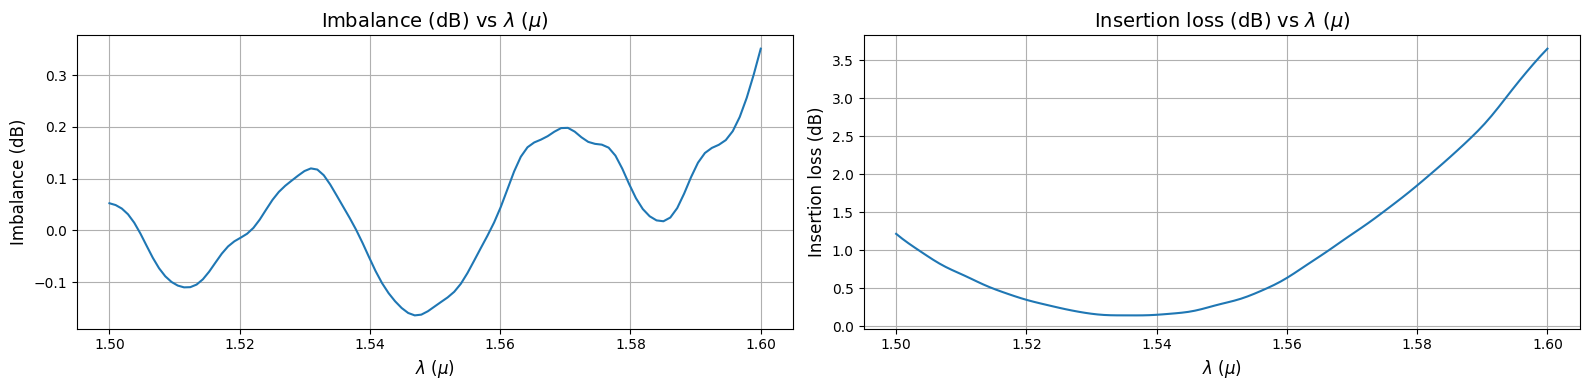

In [79]:
fig3, axs3 = plt.subplots(1,2, figsize = (16,4))

Ib = T3_dB - T4_dB

axs3[0].plot(T1["lambda"]/um, Ib, lw = 1.5)
axs3[0].set_xlabel(r"$\lambda$ ($\mu$)", fontsize = 12)
axs3[0].set_ylabel(r"Imbalance (dB)", fontsize = 12)
axs3[0].set_title(r"Imbalance (dB) vs $\lambda$ ($\mu$)", fontsize = 14)
axs3[0].grid()

Il = -10*np.log10(T3["T"]+T4["T"])
axs3[1].plot(T1["lambda"]/um, Il, lw=1.5)
axs3[1].set_xlabel(r"$\lambda$ ($\mu$)", fontsize = 12)
axs3[1].set_ylabel(r"Insertion loss (dB)", fontsize = 12)
axs3[1].set_title(r"Insertion loss (dB) vs $\lambda$ ($\mu$)", fontsize = 14)
axs3[1].grid()

"""phi1 = np.angle(S["s31"])
phi2 = np.angle(S["s41"])

phase = (phi1-phi2)*(180/np.pi)

for p in range (len(phase)):
    if (np.abs(phase[p]))>180:
        phase[p] = phase[p] + 360
    



axs3[2].plot(T1["lambda"]/um,phase, lw=1.5)
axs3[2].set_xlabel(r"$\lambda$ ($\mu$)", fontsize = 12)
axs3[2].set_ylabel(r"Phase shift (°)", fontsize = 12)
axs3[2].set_title(r"Phase shift (°) vs $\lambda$ ($\mu$)", fontsize = 14)
axs3[2].set_xlim(1.53, 1.57)
axs3[2].grid()"""

plt.tight_layout()
plt.savefig("Perdas - FDTD - TE.png")
plt.show


In [71]:
fdtdApi.close()